In [1]:

# Step 1: Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Step 2 : Create COVID Dataset

data = {
    "Country": [
        "India", "USA", "Brazil", "Russia", "Australia",
        "Argentina", "japan", "china", "afghanistan", "Canada"
    ],

    "Confirmed": [
         10000, 20000, 15000, 12000, 11000,
        13000, 9000, 8000, 7000, 9500
    ],

    "Recovered": [
        9200, 18500, 14000, 11000, 10000,
        12000, 8500, 7600, 6500, 8900
    ],

    "Deaths": [
        200, 500, 300, 250, 150,
        220, 100, 80, 120, 140
    ],

    "Date": [
        "2025-01-01", "2025-01-01", "2025-01-01",
        "2025-01-01", "2025-01-01",

        "2025-02-01", "2025-02-01", "2025-02-01",
        "2025-02-01", "2025-02-01"
    ]
}

# Create DataFrame

df = pd.DataFrame(data)
df.index = range(1, len(df) + 1)
print("--------COVID-19 DATASET-----------")

print(df)


--------COVID-19 DATASET-----------
        Country  Confirmed  Recovered  Deaths        Date
1         India      10000       9200     200  2025-01-01
2           USA      20000      18500     500  2025-01-01
3        Brazil      15000      14000     300  2025-01-01
4        Russia      12000      11000     250  2025-01-01
5     Australia      11000      10000     150  2025-01-01
6     Argentina      13000      12000     220  2025-02-01
7         japan       9000       8500     100  2025-02-01
8         china       8000       7600      80  2025-02-01
9   afghanistan       7000       6500     120  2025-02-01
10       Canada       9500       8900     140  2025-02-01


In [3]:
# Step 3 : Basic Information


print("FIRST 5 ROWS")
print(df.head(2))


print("DATASET INFORMATION")
print(df.info())


print("STATISTICAL SUMMARY")
print(df.describe())

FIRST 5 ROWS
  Country  Confirmed  Recovered  Deaths        Date
1   India      10000       9200     200  2025-01-01
2     USA      20000      18500     500  2025-01-01
DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 1 to 10
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Country    10 non-null     str  
 1   Confirmed  10 non-null     int64
 2   Recovered  10 non-null     int64
 3   Deaths     10 non-null     int64
 4   Date       10 non-null     str  
dtypes: int64(3), str(2)
memory usage: 697.0 bytes
None
STATISTICAL SUMMARY
          Confirmed     Recovered      Deaths
count     10.000000     10.000000   10.000000
mean   11450.000000  10620.000000  206.000000
std     3832.970997   3520.037879  124.472219
min     7000.000000   6500.000000   80.000000
25%     9125.000000   8600.000000  125.000000
50%    10500.000000   9600.000000  175.000000
75%    12750.000000  11750.000000  242.500000
max    200

In [4]:
# Step 4 : Data Cleaning

print("MISSING VALUES")
print(df.isnull().sum())
# Remove duplicate rows
df.drop_duplicates(inplace=True)
# Convert Date column into datetime format
df["Date"] = pd.to_datetime(df["Date"])
print("\nData Cleaning Completed Successfully!")

MISSING VALUES
Country      0
Confirmed    0
Recovered    0
Deaths       0
Date         0
dtype: int64

Data Cleaning Completed Successfully!


In [5]:
# Step 5 : Create New Columns

# Active Cases
df["Active_Cases"] = (
    df["Confirmed"] -
    df["Recovered"] -
    df["Deaths"]
)

# Recovery Rate
df["Recovery_Rate"] = (
    df["Recovered"] / df["Confirmed"]
) * 100

# Death Rate
df["Death_Rate"] = (
    df["Deaths"] / df["Confirmed"]
) * 100


print("UPDATED DATASET")

print(df)

UPDATED DATASET
        Country  Confirmed  Recovered  Deaths       Date  Active_Cases  \
1         India      10000       9200     200 2025-01-01           600   
2           USA      20000      18500     500 2025-01-01          1000   
3        Brazil      15000      14000     300 2025-01-01           700   
4        Russia      12000      11000     250 2025-01-01           750   
5     Australia      11000      10000     150 2025-01-01           850   
6     Argentina      13000      12000     220 2025-02-01           780   
7         japan       9000       8500     100 2025-02-01           400   
8         china       8000       7600      80 2025-02-01           320   
9   afghanistan       7000       6500     120 2025-02-01           380   
10       Canada       9500       8900     140 2025-02-01           460   

    Recovery_Rate  Death_Rate  
1       92.000000    2.000000  
2       92.500000    2.500000  
3       93.333333    2.000000  
4       91.666667    2.083333  
5       9

In [6]:

# Step 6 : NumPy Operations

confirmed_array = np.array(df["Confirmed"])


print("NUMPY OPERATIONS")

print("Confirmed Cases Array:")
print(confirmed_array)

print("\nMaximum Cases :", np.max(confirmed_array))
print("Minimum Cases :", np.min(confirmed_array))
print("Average Cases :", np.mean(confirmed_array))
print("Total Cases   :", np.sum(confirmed_array))



NUMPY OPERATIONS
Confirmed Cases Array:
[10000 20000 15000 12000 11000 13000  9000  8000  7000  9500]

Maximum Cases : 20000
Minimum Cases : 7000
Average Cases : 11450.0
Total Cases   : 114500


In [7]:
# Step 7 : Country-wise Analysis

country_analysis = df.groupby("Country")[[
    "Confirmed",
    "Recovered",
    "Deaths",
    "Active_Cases"
]].sum()

print("COUNTRY-WISE ANALYSIS")

print(country_analysis)

COUNTRY-WISE ANALYSIS
             Confirmed  Recovered  Deaths  Active_Cases
Country                                                
Argentina        13000      12000     220           780
Australia        11000      10000     150           850
Brazil           15000      14000     300           700
Canada            9500       8900     140           460
India            10000       9200     200           600
Russia           12000      11000     250           750
USA              20000      18500     500          1000
afghanistan       7000       6500     120           380
china             8000       7600      80           320
japan             9000       8500     100           400


In [8]:
# Step 8 : Sort by Confirmed Cases


top_countries = country_analysis.sort_values(
    by="Confirmed",
    ascending=False
)


print("TOP COUNTRIES BY CONFIRMED CASES")

print(top_countries)


TOP COUNTRIES BY CONFIRMED CASES
             Confirmed  Recovered  Deaths  Active_Cases
Country                                                
USA              20000      18500     500          1000
Brazil           15000      14000     300           700
Argentina        13000      12000     220           780
Russia           12000      11000     250           750
Australia        11000      10000     150           850
India            10000       9200     200           600
Canada            9500       8900     140           460
japan             9000       8500     100           400
china             8000       7600      80           320
afghanistan       7000       6500     120           380


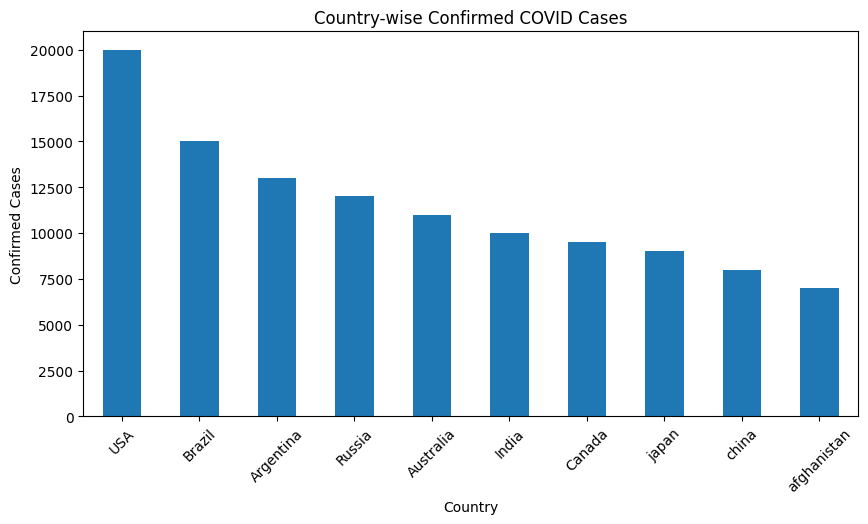

In [9]:
# Step 9 : Visualization

# Bar Chart : Confirmed Cases

plt.figure(figsize=(10,5))

top_countries["Confirmed"].plot(kind="bar")

plt.title("Country-wise Confirmed COVID Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")

plt.xticks(rotation=45)

plt.show()  

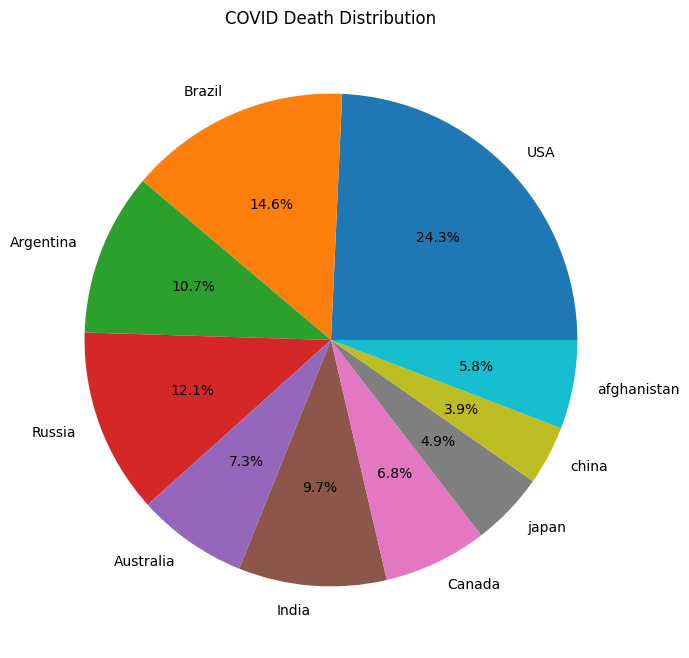

In [10]:
# Pie Chart : Death Distribution


plt.figure(figsize=(8, 8))

top_countries["Deaths"].plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("COVID Death Distribution")
plt.ylabel("")

plt.show()


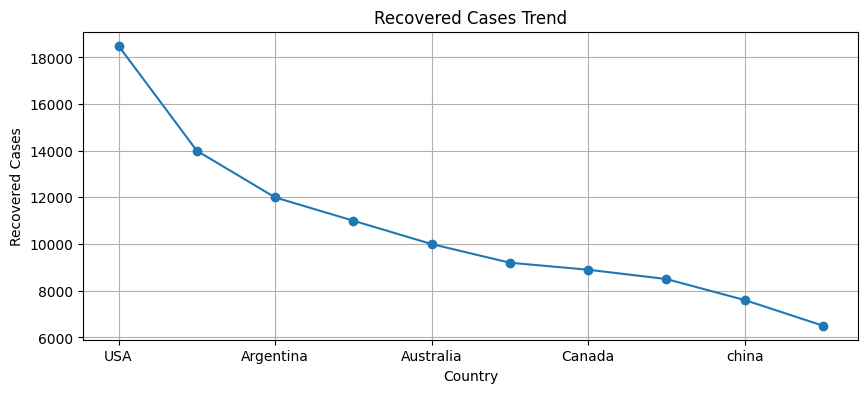

In [11]:
# Line Chart : Recovery Trend


plt.figure(figsize=(10, 4))

top_countries["Recovered"].plot(
    kind="line",
    marker="o"
)

plt.title("Recovered Cases Trend")
plt.xlabel("Country")
plt.ylabel("Recovered Cases")

plt.grid(True)

plt.show()
